In [1]:
import pandas as pd
import numpy as np

# -------------------------
# POLICY SALES DATA
# -------------------------

total_customers = 1000000
vehicle_value = 100000

# Generate IDs
customer_ids = np.arange(1, total_customers+1)
vehicle_ids = customer_ids

# Generate purchase dates evenly across 2024
dates = pd.date_range("2024-01-01","2024-12-31")
purchase_dates = np.tile(dates, int(np.ceil(total_customers/len(dates))))[:total_customers]

# Tenure distribution
tenure = np.random.choice(
    [1,2,3,4],
    size=total_customers,
    p=[0.20,0.30,0.40,0.10]
)

premium = tenure * 100

policy_start = pd.to_datetime(purchase_dates) + pd.Timedelta(days=365)
policy_end = policy_start + pd.to_timedelta(tenure*365, unit='D')

policy_sales = pd.DataFrame({
    "Customer_ID": customer_ids,
    "Vehicle_ID": vehicle_ids,
    "Vehicle_Value": vehicle_value,
    "Premium": premium,
    "Policy_Purchase_Date": purchase_dates,
    "Policy_Start_Date": policy_start,
    "Policy_End_Date": policy_end,
    "Policy_Tenure": tenure
})

policy_sales.to_csv("policy_sales_data.csv", index=False)

# -------------------------
# CLAIMS DATA
# -------------------------

claims = []

claim_amount = vehicle_value * 0.10
claim_id = 1

# 2025 claims
claim_days = [7,14,21,28]

eligible_2025 = policy_sales[
    policy_sales["Policy_Purchase_Date"].dt.day.isin(claim_days)
]

sample_2025 = eligible_2025.sample(frac=0.30)

for _, row in sample_2025.iterrows():
    if row["Policy_Start_Date"] <= pd.Timestamp("2025-12-31"):
        claims.append([
            claim_id,
            row["Customer_ID"],
            row["Vehicle_ID"],
            claim_amount,
            row["Policy_Start_Date"],
            1
        ])
        claim_id += 1

# 2026 claims (10% of 4 year tenure)
tenure4 = policy_sales[policy_sales["Policy_Tenure"] == 4]
sample_2026 = tenure4.sample(frac=0.10)

dates_2026 = pd.date_range("2026-01-01","2026-02-28")

for i, (_, row) in enumerate(sample_2026.iterrows()):
    claim_date = dates_2026[i % len(dates_2026)]

    if row["Policy_Start_Date"] <= claim_date <= row["Policy_End_Date"]:
        claims.append([
            claim_id,
            row["Customer_ID"],
            row["Vehicle_ID"],
            claim_amount,
            claim_date,
            2
        ])
        claim_id += 1

claims_df = pd.DataFrame(claims, columns=[
    "Claim_ID",
    "Customer_ID",
    "Vehicle_ID",
    "Claim_Amount",
    "Claim_Date",
    "Claim_Type"
])

claims_df.to_csv("claims_data.csv", index=False)

print("Datasets created successfully!")

Datasets created successfully!


In [3]:
policy = pd.read_csv("policy_sales_data.csv", parse_dates=["Policy_Purchase_Date"])
total_premium_2024 = policy["Premium"].sum()

print("Total Premium Collected in 2024:", total_premium_2024)

Total Premium Collected in 2024: 239988500


In [4]:
claims = pd.read_csv("claims_data.csv", parse_dates = ["Claim_Date"])
claims["Year"] = claims["Claim_Date"].dt.year
claims["Month"] = claims["Claim_Date"].dt.month

monthly_claims = claims.groupby(["Year","Month"])["Claim_Amount"].sum().reset_index()

print(monthly_claims)


    Year  Month  Claim_Amount
0   2025      1    32170000.0
1   2025      2    32800000.0
2   2025      3    33400000.0
3   2025      4    32780000.0
4   2025      5    32060000.0
5   2025      6    33480000.0
6   2025      7    32310000.0
7   2025      8    32650000.0
8   2025      9    33000000.0
9   2025     10    32680000.0
10  2025     11    33000000.0
11  2025     12    33110000.0
12  2026      1    52560000.0
13  2026      2    47320000.0


In [5]:
pivot_claims = monthly_claims.pivot(index="Month", columns="Year", values="Claim_Amount")
print(pivot_claims)

Year         2025        2026
Month                        
1      32170000.0  52560000.0
2      32800000.0  47320000.0
3      33400000.0         NaN
4      32780000.0         NaN
5      32060000.0         NaN
6      33480000.0         NaN
7      32310000.0         NaN
8      32650000.0         NaN
9      33000000.0         NaN
10     32680000.0         NaN
11     33000000.0         NaN
12     33110000.0         NaN


In [6]:
merged = claims.merge(policy, on=["Customer_ID","Vehicle_ID"])

premium_by_tenure = policy.groupby("Policy_Tenure")["Premium"].sum()

claim_by_tenure = merged.groupby("Policy_Tenure")["Claim_Amount"].sum()

ratio = (claim_by_tenure / premium_by_tenure).reset_index()
ratio.columns = ["Policy_Tenure","Claim_to_Premium_Ratio"]

print(ratio)

   Policy_Tenure  Claim_to_Premium_Ratio
0              1                3.862485
1              2                1.964301
2              3                1.325710
3              4                3.481177


In [7]:
policy["Sale_Month"] = policy["Policy_Purchase_Date"].dt.month

merged = claims.merge(policy, on=["Customer_ID","Vehicle_ID"])

premium_month = policy.groupby("Sale_Month")["Premium"].sum()

claim_month = merged.groupby("Sale_Month")["Claim_Amount"].sum()

ratio_month = (claim_month / premium_month).reset_index()
ratio_month.columns = ["Sale_Month","Claim_to_Premium_Ratio"]

print(ratio_month)

    Sale_Month  Claim_to_Premium_Ratio
0            1                2.023772
1            2                2.158734
2            3                2.060775
3            4                2.072940
4            5                1.997230
5            6                2.116169
6            7                1.985234
7            8                2.042755
8            9                2.087173
9           10                2.022820
10          11                2.093272
11          12                2.017617


In [8]:
total_customers = policy.shape[0]

customers_with_claim = claims["Customer_ID"].nunique()

remaining_customers = total_customers - customers_with_claim

claim_amount = 100000 * 0.10

potential_liability = remaining_customers * claim_amount

print("Potential Claim Liability:", potential_liability)

Potential Claim Liability: 9510250000.0


In [9]:
policy["Policy_Start_Date"] = pd.to_datetime(policy["Policy_Start_Date"])
policy["Policy_End_Date"] = pd.to_datetime(policy["Policy_End_Date"])

cutoff = pd.Timestamp("2026-02-28")

policy["Total_Tenure_Days"] = (policy["Policy_End_Date"] - policy["Policy_Start_Date"]).dt.days

policy["Daily_Premium"] = policy["Premium"] / policy["Total_Tenure_Days"]

policy["Earned_Days"] = (cutoff - policy["Policy_Start_Date"]).dt.days

policy["Earned_Days"] = policy["Earned_Days"].clip(lower=0)

policy["Earned_Premium"] = policy["Daily_Premium"] * policy["Earned_Days"]

earned_premium_total = policy["Earned_Premium"].sum()

print("Earned Premium until Feb 28 2026:", earned_premium_total)

Earned Premium until Feb 28 2026: 66167734.79452053


In [10]:
policy["Remaining_Days"] = (policy["Policy_End_Date"] - cutoff).dt.days
policy["Remaining_Days"] = policy["Remaining_Days"].clip(lower=0)

policy["Remaining_Premium"] = policy["Daily_Premium"] * policy["Remaining_Days"]

remaining_premium_total = policy["Remaining_Premium"].sum()

monthly_estimate = remaining_premium_total / 46

print("Expected Monthly Earned Premium:", monthly_estimate)

Expected Monthly Earned Premium: 3784516.235854674


In [11]:
import pandas as pd

policy = pd.read_csv("policy_sales_data.csv")
claims = pd.read_csv("claims_data.csv")

merged = claims.merge(policy, on=["Customer_ID","Vehicle_ID"])

premium_by_tenure = policy.groupby("Policy_Tenure")["Premium"].sum()
claims_by_tenure = merged.groupby("Policy_Tenure")["Claim_Amount"].sum()

analysis = pd.DataFrame({
    "Total_Premium": premium_by_tenure,
    "Total_Claims": claims_by_tenure
}).fillna(0)

analysis["Loss_Ratio"] = analysis["Total_Claims"] / analysis["Total_Premium"]

print(analysis)

               Total_Premium  Total_Claims  Loss_Ratio
Policy_Tenure                                         
1                   20041500    77410000.0    3.862485
2                   59833000   117530000.0    1.964301
3                  120162000   159300000.0    1.325710
4                   39952000   139080000.0    3.481177


In [12]:
total_premium = policy["Premium"].sum()

total_claims = claims["Claim_Amount"].sum()

loss_ratio = total_claims / total_premium

print("Portfolio Loss Ratio:", loss_ratio)

Portfolio Loss Ratio: 2.0555984974280017


In [13]:
current_claims = claims["Claim_Amount"].sum()

In [14]:
growth_rate = 0.05

claims_year1 = current_claims * (1 + growth_rate)
claims_year2 = current_claims * (1 + growth_rate)**2
claims_year3 = current_claims * (1 + growth_rate)**3

print(claims_year1, claims_year2, claims_year3)

517986000.0 543885300.0 571079565.0000001


In [15]:
new_loss_ratio = claims_year1 / total_premium

In [ ]:
2. Build a simple dashboard or visualization showing claim trends by month.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
claims = pd.read_csv("claims_data.csv")

# Convert date column
claims["Claim_Date"] = pd.to_datetime(claims["Claim_Date"])

# Create Year-Month column
claims["YearMonth"] = claims["Claim_Date"].dt.to_period("M")

# Aggregate claim amount per month
monthly_claims = claims.groupby("YearMonth")["Claim_Amount"].sum().reset_index()

monthly_claims["YearMonth"] = monthly_claims["YearMonth"].astype(str)

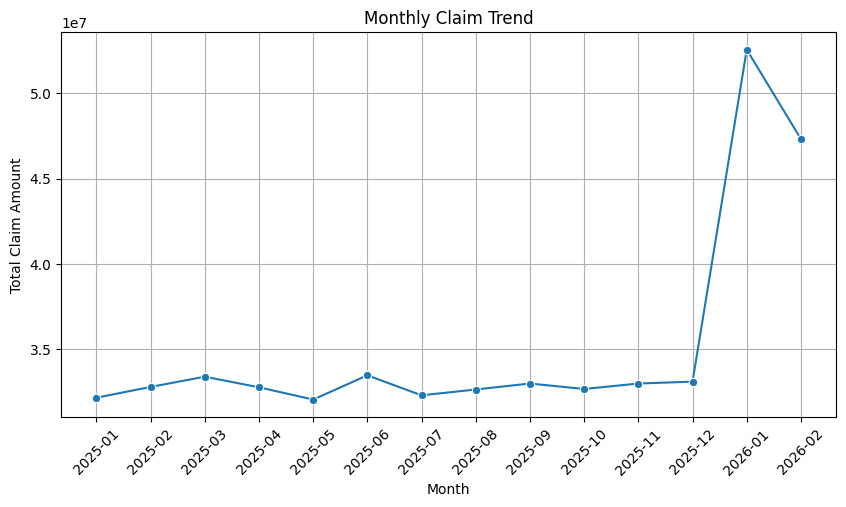

In [21]:


plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_claims,
    x="YearMonth",
    y="Claim_Amount",
    marker="o"
)

plt.title("Monthly Claim Trend")
plt.xlabel("Month")
plt.ylabel("Total Claim Amount")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_12148\2533793165.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


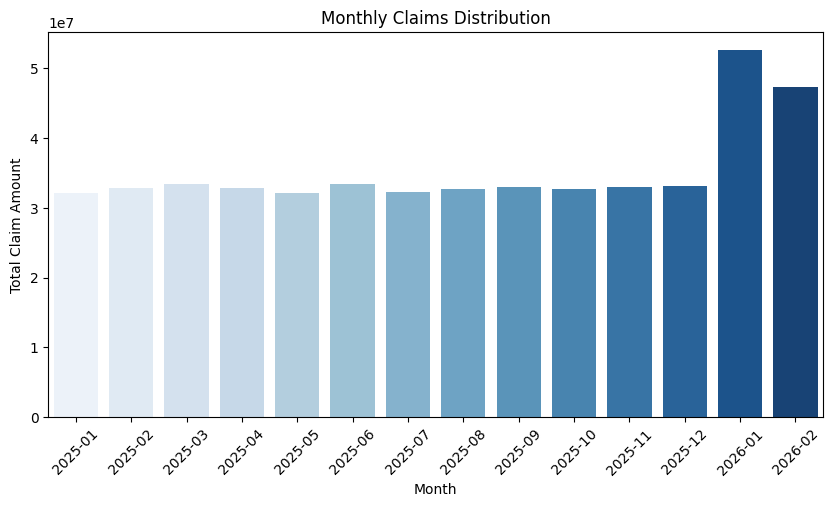

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=monthly_claims,
    x="YearMonth",
    y="Claim_Amount",
    palette="Blues"
)

plt.title("Monthly Claims Distribution")
plt.xlabel("Month")
plt.ylabel("Total Claim Amount")
plt.xticks(rotation=45)

plt.show()